# Exploratory analysis of how inequalities are reflected in Olympic Games over time

In [396]:
%matplotlib inline

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go

sns.set_theme(style="whitegrid", context="talk")
pio.templates.default = "plotly_white"

plt.rcParams.update({
    "figure.figsize": (13, 6),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.titlesize": 18,
    "legend.frameon": False,
})

PALETTES = {
    "main": sns.color_palette("viridis", 8),
    "warm": sns.color_palette("magma", 8),
    "cool": sns.color_palette("crest", 8),
    "gender": {"F": "#d14988", "M": "#2f6690", "Women": "#d14988", "Men": "#2f6690"},
    "medals": {"Gold": "#D4AF37", "Silver": "#9AA0A6", "Bronze": "#B87333"},
    "conflict": {True: "#c1121f", False: "#669bbc"},
}


def polish_axes(ax, title, subtitle=None, xlabel=None, ylabel=None):
    ax.set_title(title, loc="left", pad=16)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=11, color="#555555")
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.25)
    return ax


## 1 Dataset Preprocessing

Datasets were merged and cleaned in [merge_datasets.ipynb](merge_datasets.ipynb)

### 1.1 Dataset overview

In [397]:
olympics = pd.read_csv("../../data/olympics.csv")
print("Entries in Olympics Dataset:", olympics.shape[0])
print("Olympics Dataset Columns:", ", ".join(olympics.columns))
print("Years:", olympics["year"].min(), "-", olympics["year"].max())
print("Countries:", olympics["country"].nunique())
print("Sports:", olympics["sport"].nunique())
print("Events:", olympics["event"].nunique())
print("Athlete records:", len(olympics))

Entries in Olympics Dataset: 271116
Olympics Dataset Columns: id, name, gender, age, height, weight, team, noc, country, population, year, season, city, sport, event, medal, gdp_per_capita, conflict_name, conflict_start, conflict_end, conflict_reason, conflict_result
Years: 1896 - 2016
Countries: 205
Sports: 66
Events: 765
Athlete records: 271116


## 2 Participation Analysis

### 2.1 Participation over time

In [398]:
def plot_participation_by_season(df, season_name):

    athletes = (
        df.groupby(["year", "season", "gender"])
        .size()
        .reset_index(name="athletes")
    )

    season_data = athletes[athletes["season"] == season_name]

    fig, ax = plt.subplots(figsize=(14, 6))

    for gender, label in zip(["F", "M"], ["Women", "Men"]):

        data = season_data[season_data["gender"] == gender]

        ax.plot(
            data["year"],
            data["athletes"],
            linewidth=2.8,
            marker="o",
            markersize=5,
            label=label,
            color=PALETTES["gender"][gender],
        )

        ax.fill_between(
            data["year"],
            data["athletes"],
            alpha=0.15,
            color=PALETTES["gender"][gender],
        )

    polish_axes(
        ax,
        f"{season_name} Olympics Participation Over Time",
        "Athlete Records",
        "Year",
    )

    ax.legend()
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

    plt.tight_layout()
    plt.show()

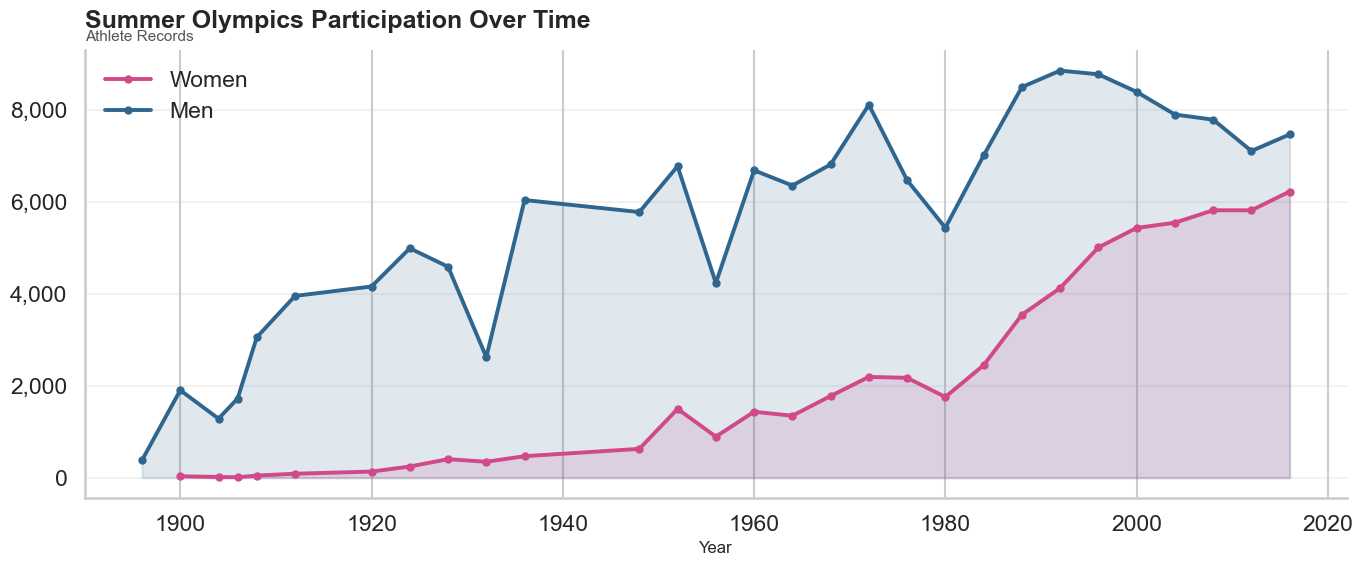

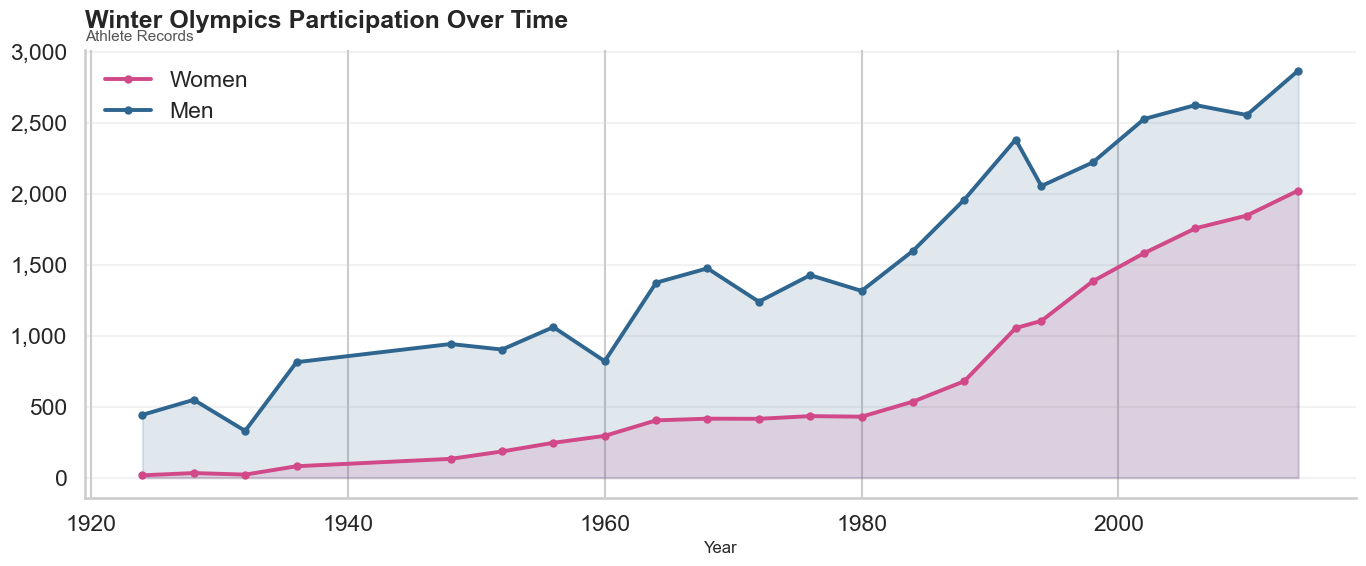

In [399]:
plot_participation_by_season(olympics, "Summer")
plot_participation_by_season(olympics, "Winter")

### 2.2 Participating countries 

In [ ]:
def plot_countries(season):
    
    # filter INSIDE the function (dataset is assumed global)
    df = olympics[olympics["season"] == season]

    countries_by_year = (
        df.groupby("year")["country"]
        .apply(lambda x: sorted(set(x.dropna().astype(str))))
        .reset_index(name="country_list")
    )

    seen_countries = set()
    new_counts = []
    new_country_lists = []

    for countries in countries_by_year["country_list"]:
        current = set(countries)
        new_countries = sorted(current - seen_countries)

        new_counts.append(len(new_countries))
        new_country_lists.append(", ".join(new_countries) if new_countries else "None")

        seen_countries.update(current)

    countries_by_year["countries"] = countries_by_year["country_list"].apply(len)
    countries_by_year["new_countries_count"] = new_counts
    countries_by_year["new_countries"] = new_country_lists

    # ONLY BAR CHART (no trend line)
    fig = go.Figure()

    fig.add_trace(
        go.Bar(
            x=countries_by_year["year"],
            y=countries_by_year["countries"],
            customdata=countries_by_year[["new_countries_count", "new_countries"]],
            hovertemplate=(
                "<b>Year:</b> %{x}<br>"
                "<b>Total countries:</b> %{y}<br>"
                "<b>New countries added:</b> %{customdata[0]}<br>"
                "<b>Which ones:</b> %{customdata[1]}<extra></extra>"
            ),
            name="Participating countries"
        )
    )

    fig.update_layout(
        title=f"Participating Countries Over Time ({season})",
        xaxis_title="Year",
        yaxis_title="Number of countries",
        template="plotly_white",
        hoverlabel=dict(align="left"),
    )

    fig.show()

In [401]:
plot_countries("Summer")
plot_countries("Winter")

## 3 Gender Representation

### 3.1 Female participation share

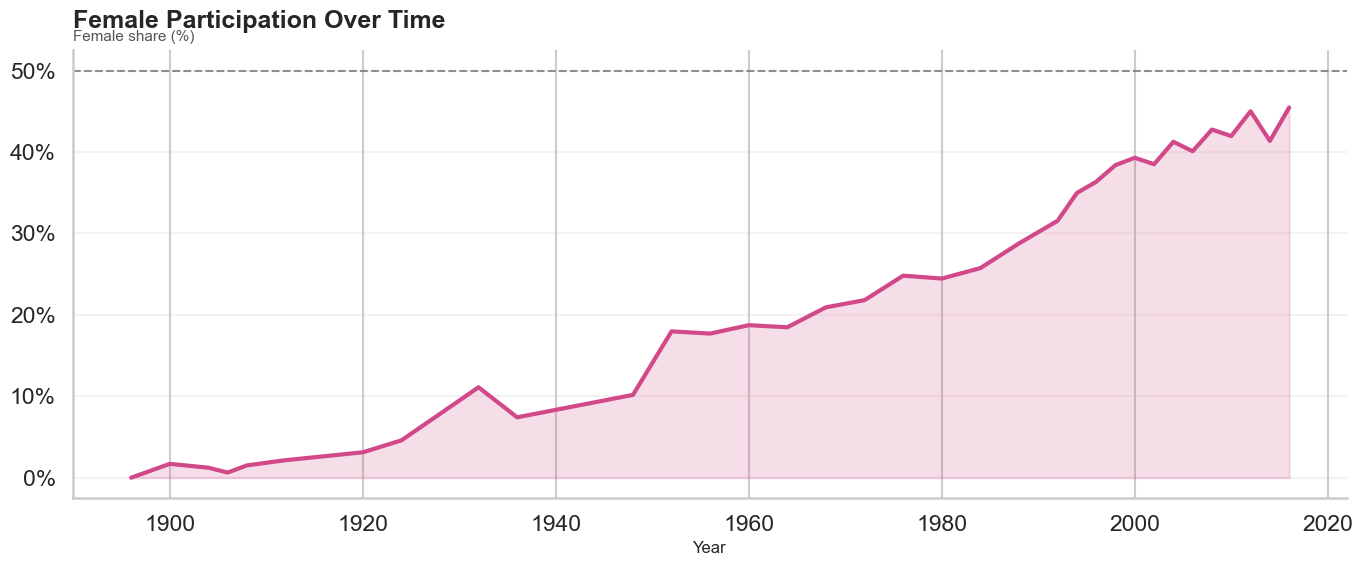

In [402]:
gender = olympics.groupby(["year","gender"]).size().unstack(fill_value=0)

gender["total"] = gender.sum(axis=1)
gender["female_share"] = 100 * gender["F"] / gender["total"]

gender = gender.reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(gender["year"], gender["female_share"], color=PALETTES["gender"]["F"], linewidth=3)
ax.fill_between(gender["year"], gender["female_share"], color=PALETTES["gender"]["F"], alpha=0.18)
ax.axhline(50, linestyle="--", linewidth=1.5, color="#6c757d", alpha=0.8)
polish_axes(
    ax,
    "Female Participation Over Time",
    "Female share (%)",
    "Year",
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()


### 3.2 Male vs female participation

In [403]:
def create_gender_plot(df, season_name):

    season_df = df[df["season"] == season_name]

    gender_time = (
        season_df
        .groupby(["year", "gender"])
        .size()
        .reset_index(name="count")
    )

    gender_time["gender"] = gender_time["gender"].replace({"M": "Men", "F": "Women"})

    all_years = sorted(gender_time["year"].unique())
    all_genders = ["Men", "Women"]

    full_index = pd.MultiIndex.from_product(
        [all_years, all_genders],
        names=["year", "gender"]
    )

    gender_time = (
        gender_time
        .set_index(["year", "gender"])
        .reindex(full_index, fill_value=0)
        .reset_index()
    )

    fig = px.bar(
        gender_time,
        x="gender",
        y="count",
        color="gender",
        animation_frame="year",
        range_y=[0, gender_time["count"].max() + 500],
        title=f"The Path to Parity: Athlete Records Over Time by Gender ({season_name} Olympics)",
        template="ggplot2",
        color_discrete_map={
            "Men": "#ADD8E6",
            "Women": "#FFB6C1"
        }
    )

    fig.update_layout(
        xaxis_title="Gender",
        yaxis_title="Number of Athlete Records"
    )

    return fig

In [404]:
fig_summer = create_gender_plot(olympics, "Summer")
fig_winter = create_gender_plot(olympics, "Winter")

fig_summer.show()
fig_winter.show()

In [405]:
import plotly.graph_objects as go

def create_gender_pie(df, season_name):
    season_df = df[df["season"] == season_name]

    gender_time = (
        season_df
        .groupby(["year", "gender"])
        .size()
        .reset_index(name="count")
    )

    gender_time["gender"] = gender_time["gender"].replace({"M": "Men", "F": "Women"})

    years = sorted(gender_time["year"].unique())

    frames = []
    slider_steps = []

    for year in years:
        data_year = gender_time[gender_time["year"] == year]

        frames.append(
            go.Frame(
                data=[
                    go.Pie(
                        labels=data_year["gender"],
                        values=data_year["count"],
                        marker=dict(colors=["#FFB6C1", "#ADD8E6"]),
                        textinfo="percent+label"
                    )
                ],
                name=str(year)
            )
        )

        slider_steps.append(
            {
                "args": [
                    [str(year)],
                    {
                        "frame": {"duration": 700, "redraw": True},
                        "mode": "immediate",
                        "transition": {"duration": 400}
                    }
                ],
                "label": str(year),
                "method": "animate"
            }
        )

    first_year = gender_time[gender_time["year"] == years[0]]

    fig = go.Figure(
        data=[
            go.Pie(
                labels=first_year["gender"],
                values=first_year["count"],
                marker=dict(colors=["#FFB6C1", "#ADD8E6"]),
                textinfo="percent+label"
            )
        ],
        frames=frames
    )

    fig.update_layout(
        title=f"Gender Distribution Over Time ({season_name} Olympics)",
        updatemenus=[
            {
                "type": "buttons",
                "direction": "left",
                "x": 0.1,
                "y": 1.15,
                "showactive": False,
                "buttons": [
                    {
                        "label": "Play",
                        "method": "animate",
                        "args": [
                            None,
                            {
                                "frame": {"duration": 700, "redraw": True},
                                "fromcurrent": True,
                                "transition": {"duration": 400}
                            }
                        ]
                    },
                    {
                        "label": "Pause",
                        "method": "animate",
                        "args": [
                            [None],
                            {
                                "frame": {"duration": 0, "redraw": False},
                                "mode": "immediate",
                                "transition": {"duration": 0}
                            }
                        ]
                    }
                ]
            }
        ],
        sliders=[
            {
                "active": 0,
                "currentvalue": {
                    "prefix": "Year: ",
                    "font": {"size": 16}
                },
                "pad": {"t": 50},
                "steps": slider_steps
            }
        ]
    )

    return fig

In [406]:
fig_summer = create_gender_pie(olympics, "Summer")
fig_winter = create_gender_pie(olympics, "Winter")

fig_summer.show()
fig_winter.show()

In [407]:
gender_share = (
    olympics.groupby(["year", "gender"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={"F": "Women", "M": "Men"})
)

gender_share["total"] = gender_share.sum(axis=1)
gender_share["women_share"] = 100 * gender_share["Women"] / gender_share["total"]

print("Women's Share of Athlete Records by Year:")
gender_share[["Women", "Men", "women_share"]].tail(10)

Women's Share of Athlete Records by Year:


gender,Women,Men,women_share
year,,,
1998,1384,2221,38.391123
2000,5431,8390,39.295275
2002,1582,2527,38.500852
2004,5546,7897,41.255672
2006,1757,2625,40.095847
2008,5816,7786,42.758418
2010,1847,2555,41.958201
2012,5815,7105,45.007740
2014,2023,2868,41.361685


In [408]:
sport_gender = (
    olympics.groupby(["sport", "gender"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={"F": "Women", "M": "Men"})
)

sport_gender["total"] = sport_gender.sum(axis=1)
sport_gender["women_share"] = 100 * sport_gender["Women"] / sport_gender["total"]

sport_gender.sort_values("women_share").head(10)

gender,Women,Men,total,women_share
sport,,,,
Aeronautics,0,1,1,0.0
Baseball,0,894,894,0.0
Cricket,0,24,24,0.0
Basque Pelota,0,2,2,0.0
Jeu De Paume,0,11,11,0.0
Nordic Combined,0,1344,1344,0.0
Military Ski Patrol,0,24,24,0.0
Lacrosse,0,60,60,0.0
Tug-Of-War,0,170,170,0.0


## 4 Sports Distribution

### 4.1 Most common sports

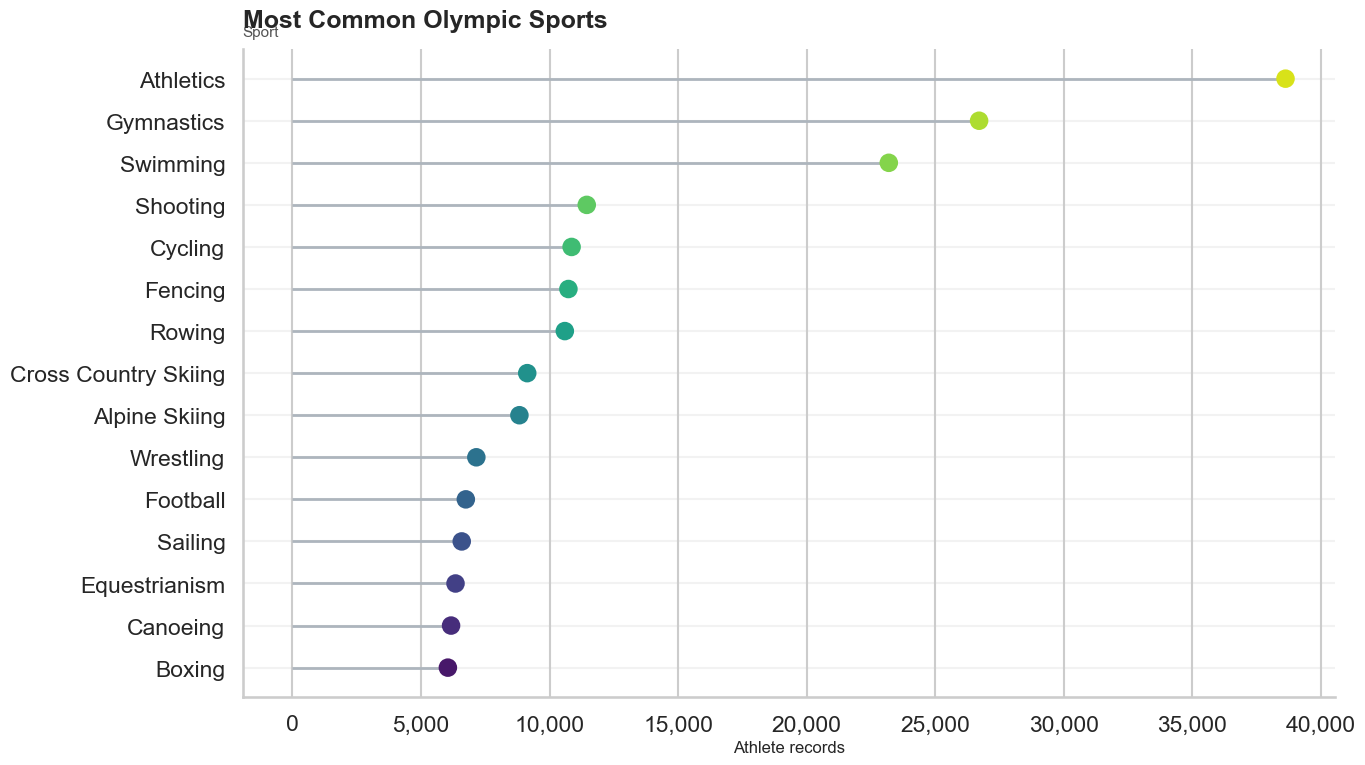

In [409]:
top_sports = olympics["sport"].value_counts().head(15).sort_values()

fig, ax = plt.subplots(figsize=(14, 8))
ax.hlines(y=top_sports.index, xmin=0, xmax=top_sports.values, color="#adb5bd", linewidth=2)
ax.scatter(top_sports.values, top_sports.index, s=140, c=sns.color_palette("viridis", len(top_sports)), zorder=3)
polish_axes(
    ax,
    "Most Common Olympic Sports",
    "Sport",
    "Athlete records",
)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout()
plt.show()


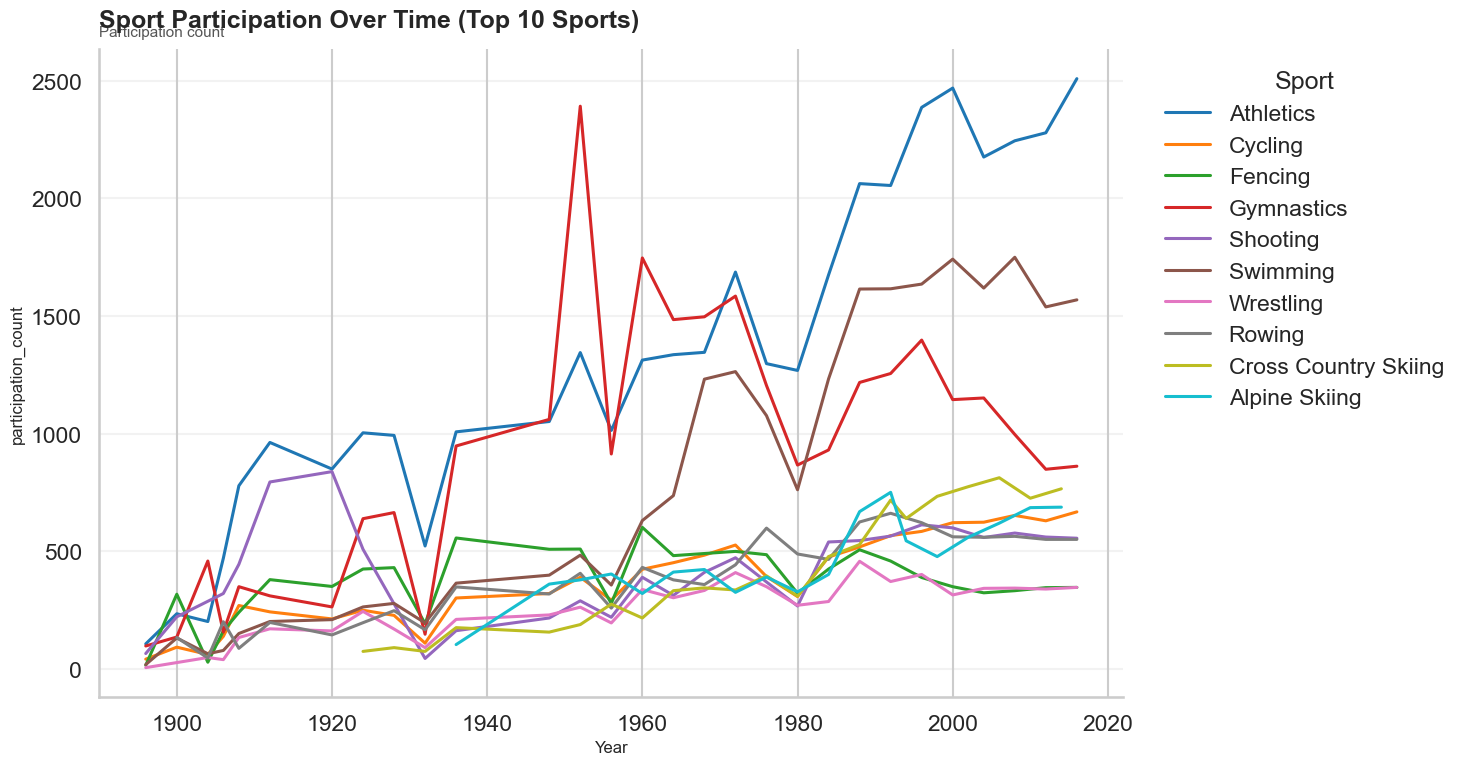

In [410]:
sport_year = (
    olympics.groupby(["year", "sport"])
    .size()
    .reset_index(name="participation_count")
)

# Top sports only
top_sports = (
    sport_year.groupby("sport")["participation_count"]
    .sum()
    .nlargest(10)
    .index
)

sport_year_top = sport_year[sport_year["sport"].isin(top_sports)]

plt.figure(figsize=(15, 8))
ax = sns.lineplot(
    data=sport_year_top,
    x="year",
    y="participation_count",
    hue="sport",
    palette="tab10",
    linewidth=2.2,
)
polish_axes(
    ax,
    "Sport Participation Over Time (Top 10 Sports)",
    "Participation count",
    "Year",
)
plt.legend(title="Sport", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [411]:
year_summary = (
    olympics.groupby("year")
    .agg(
        sports=("sport", "nunique"),
        events=("event", "nunique"),
        regions=("country", "nunique")
    )
    .reset_index()
)

year_summary.head()

,year,sports,events,regions
0,1896,9,43,12
1,1900,20,90,31
2,1904,18,95,14
3,1906,13,74,20
4,1908,24,109,22


### 4.2 Female representation by sport

In [412]:
def plot_gender_share(df, gender):

    sport_gender = df.groupby(["sport", "gender"]).size().unstack(fill_value=0)

    sport_gender["total"] = sport_gender.sum(axis=1)

    if gender == "F":
        sport_gender["share"] = 100 * sport_gender["F"] / sport_gender["total"]
        title = "Sports with Highest Female Share"
        color_point = "#bc5090"
        color_line = "#f3c4d7"
        label = "Female share (%)"
    else:
        sport_gender["share"] = 100 * sport_gender["M"] / sport_gender["total"]
        title = "Sports with Highest Male Share"
        color_point = "#355070"
        color_line = "#a8dadc"
        label = "Male share (%)"

    sport_gender = sport_gender[sport_gender["total"] > 100]

    top_share = (
        sport_gender.sort_values("share", ascending=False)
        .head(10)
        .sort_values("share")
    )

    fig, ax = plt.subplots(figsize=(14, 7))

    ax.scatter(top_share["share"], top_share.index, s=160, color=color_point)

    for y, val in enumerate(top_share["share"]):
        ax.hlines(
            y=top_share.index[y],
            xmin=0,
            xmax=val,
            color=color_line,
            linewidth=3
        )

    polish_axes(
        ax,
        title,
        "Sport",
        label,
    )

    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    plt.tight_layout()
    plt.show()

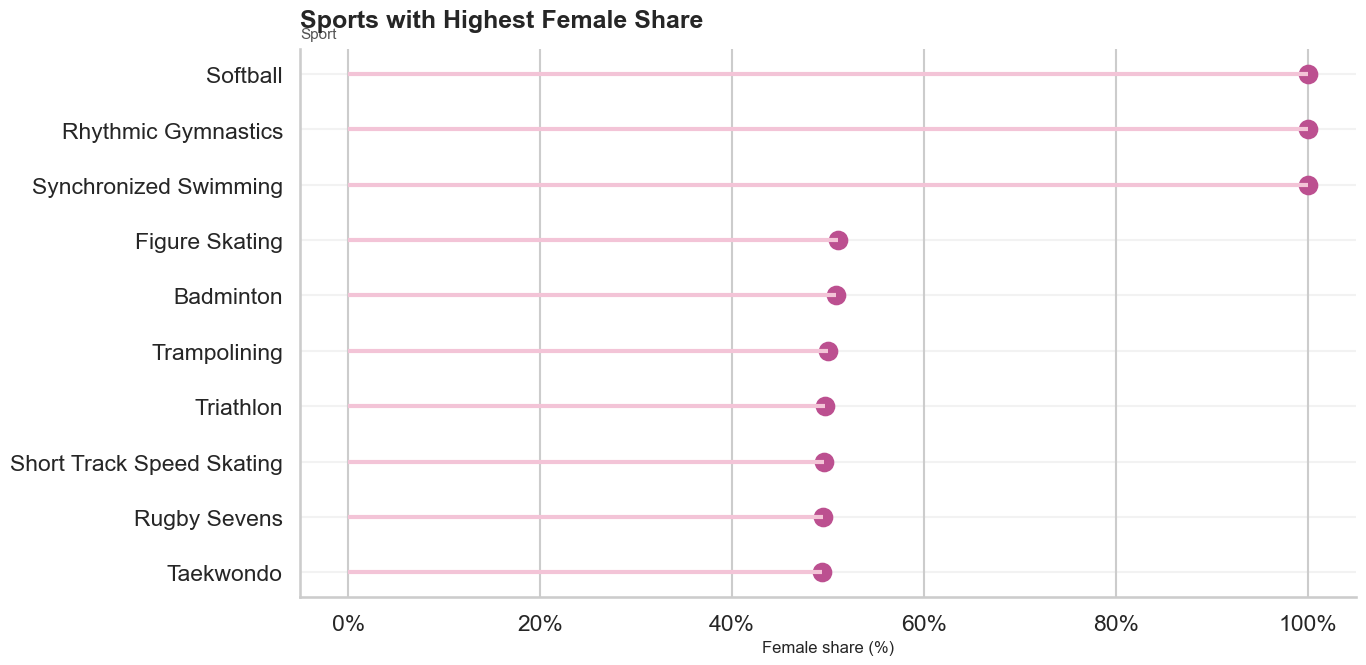

In [413]:
plot_gender_share(olympics, "F")

### 4.3 Male representation by sport

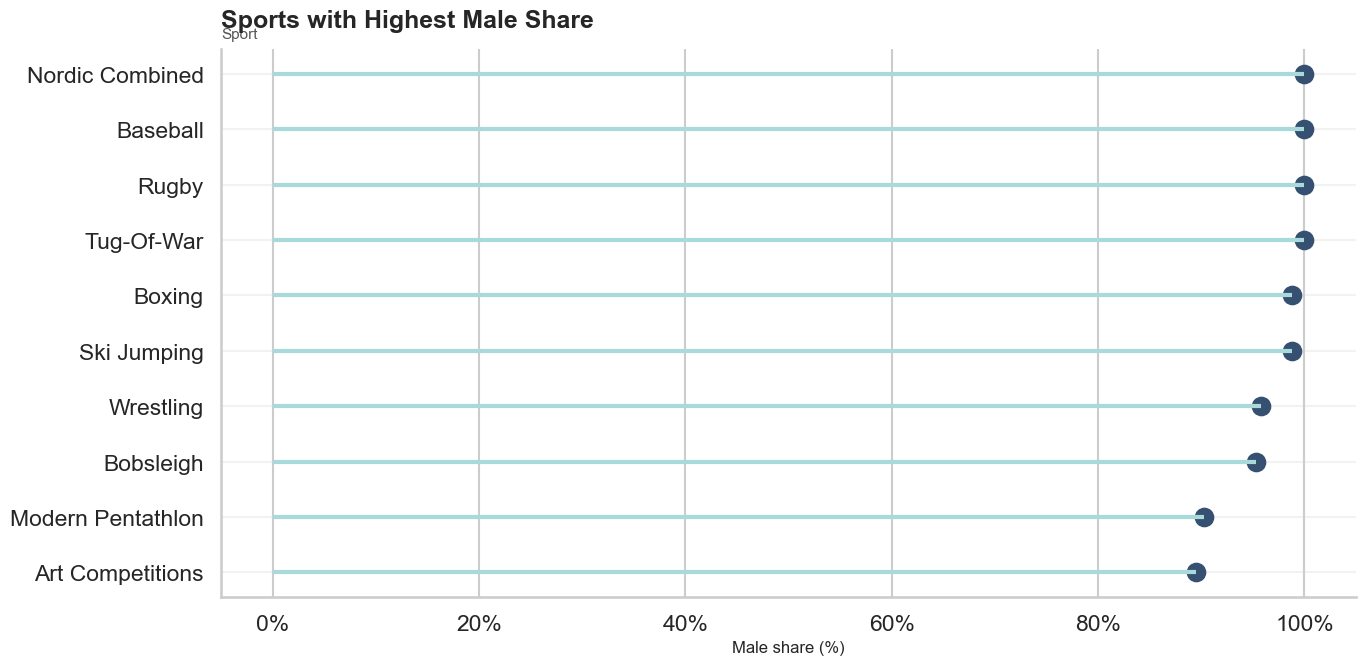

In [414]:
plot_gender_share(olympics, "M")

## 5 Countries & Medals

### 5.1 Countries with largest delegations

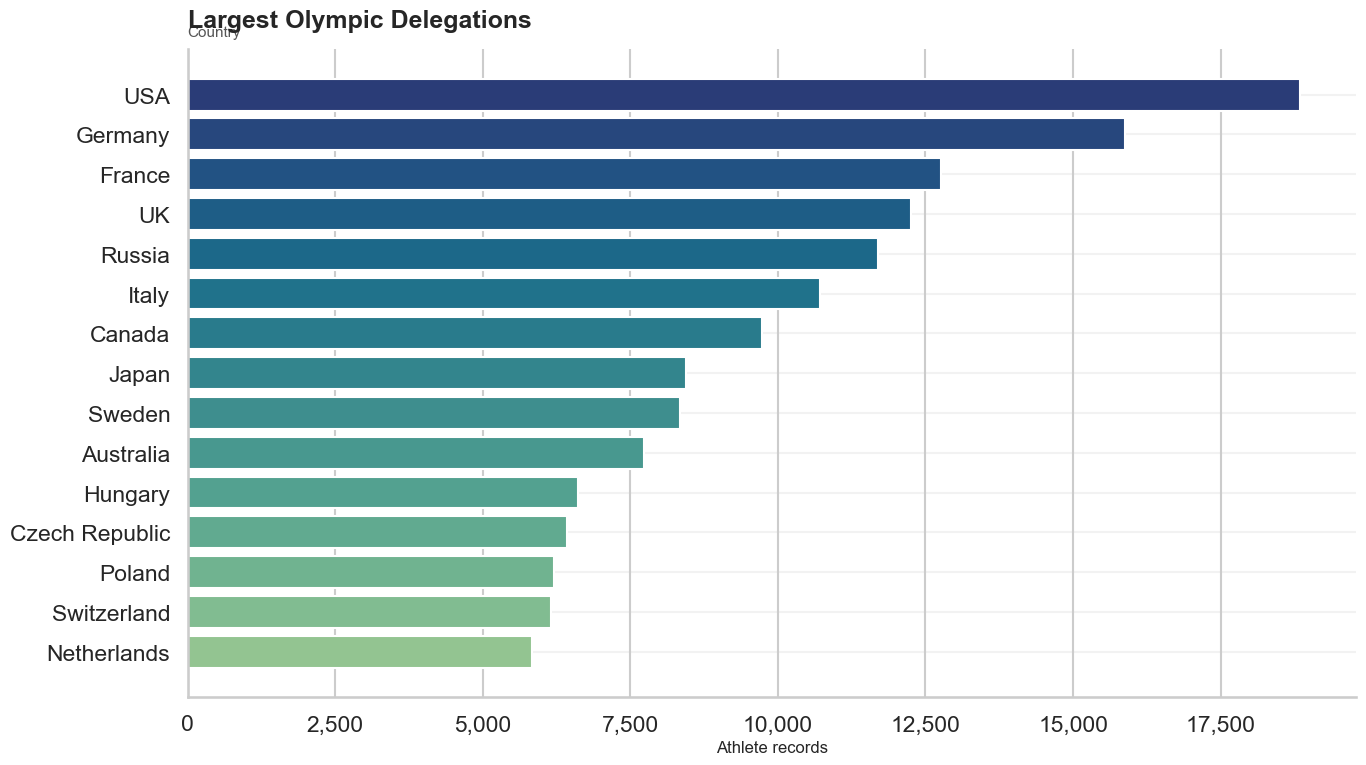

In [415]:
top_countries = olympics["country"].value_counts().head(15).sort_values()

fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(top_countries.index, top_countries.values, color=sns.color_palette("crest", len(top_countries)))
polish_axes(
    ax,
    "Largest Olympic Delegations",
    "Country",
    "Athlete records",
)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout()
plt.show()


In [416]:
region_year = (
    olympics.groupby(["year", "country"])
    .size()
    .reset_index(name="count")
)

print("Countries with the most athlete records:")
olympics["country"].value_counts().head(10)

Countries with the most athlete records:


country
USA          18853
Germany      15883
France       12758
UK           12256
Russia       11692
Italy        10715
Canada        9734
Japan         8444
Sweden        8339
Australia     7724
Name: count, dtype: int64

### 5.2 Countries with most medals

In [417]:
def plot_top_countries_medals(season, top_n=15):
    
    medals = olympics[
        (olympics["medal"].notna()) &
        (olympics["season"] == season)
    ]

    medal_counts = (
        medals.groupby("country")
        .size()
        .sort_values(ascending=False)
        .head(top_n)
        .sort_values()
    )

    # Choose color palette based on season
    if season == "Summer":
        colors = sns.color_palette("YlOrBr", len(medal_counts))
    else:  # Winter
        colors = sns.color_palette("Blues", len(medal_counts))

    fig, ax = plt.subplots(figsize=(14, 8))

    ax.barh(
        medal_counts.index,
        medal_counts.values,
        color=colors
    )

    polish_axes(
        ax,
        f"Top Countries by Medal Count ({season})",
        "Country",
        "Medal count",
    )

    ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

    plt.tight_layout()
    plt.show()

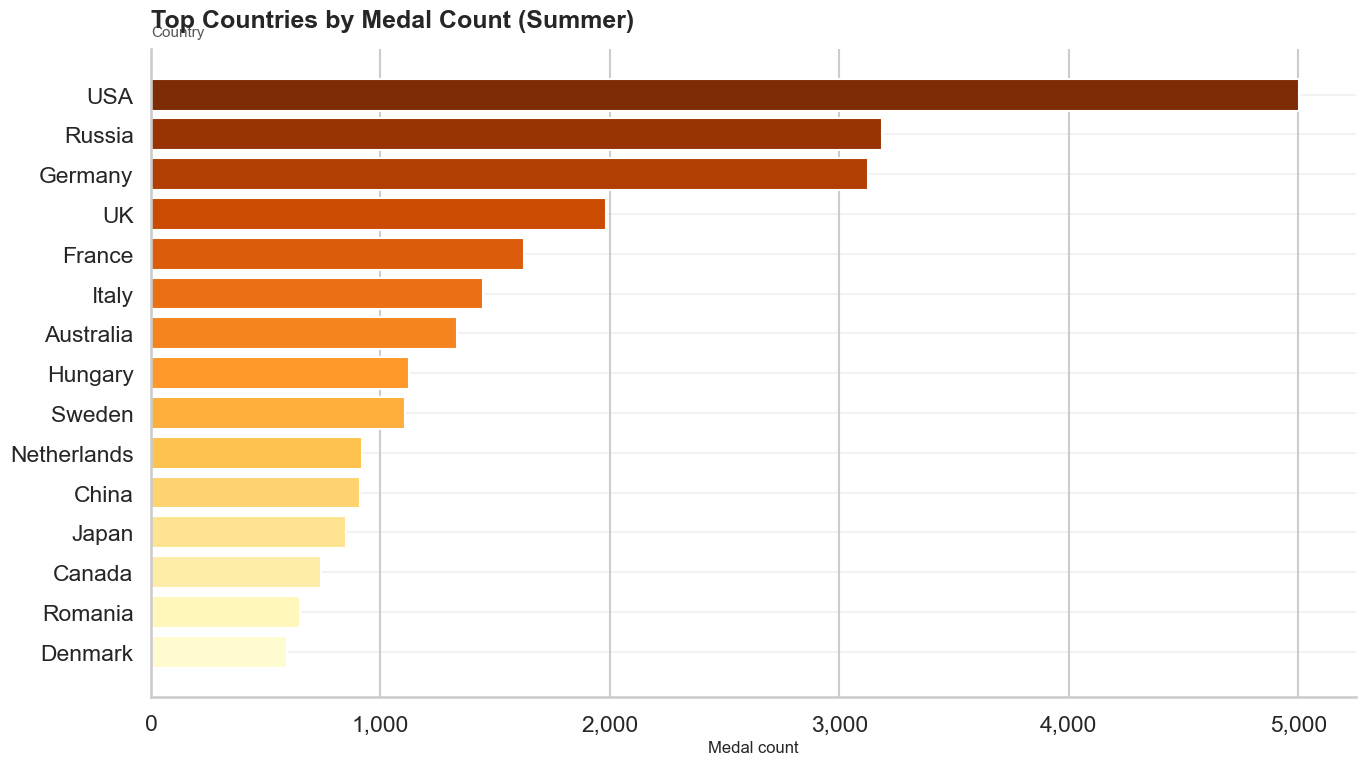

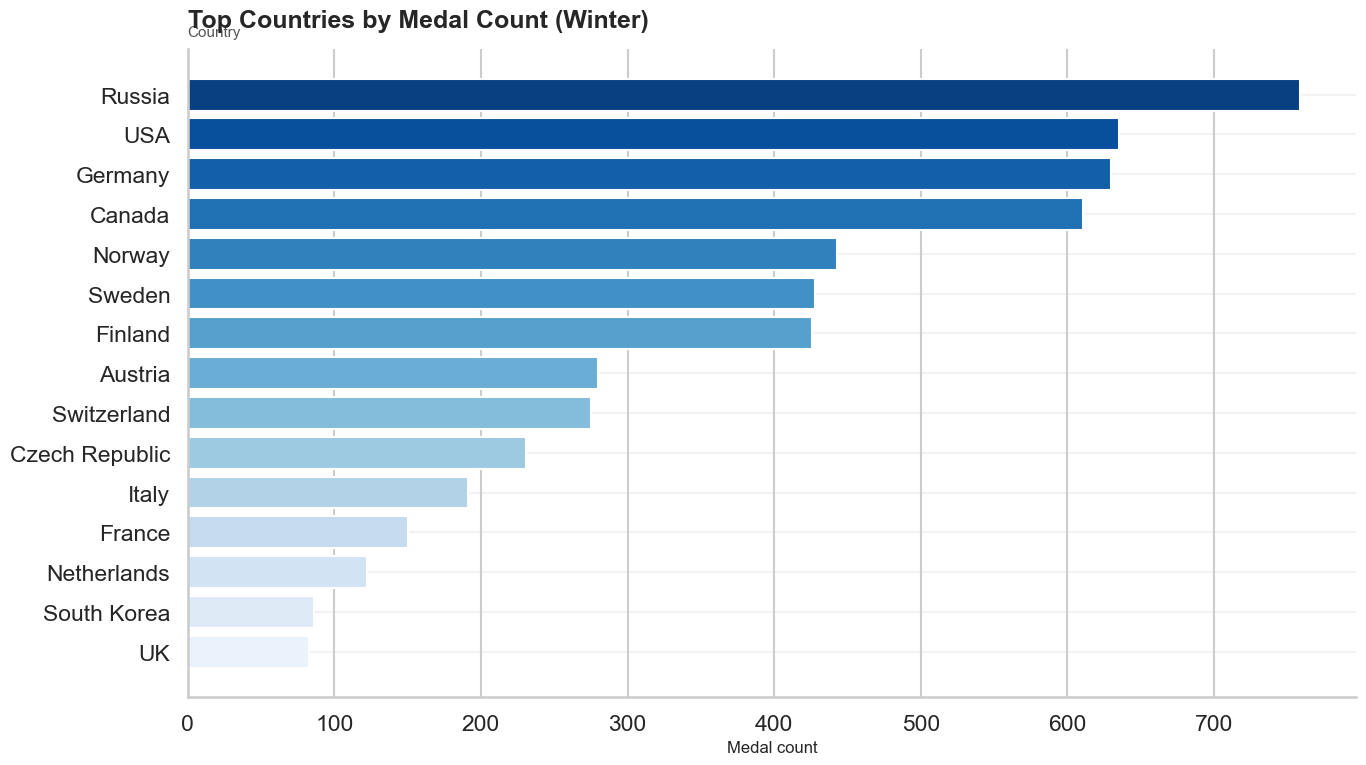

In [418]:
plot_top_countries_medals("Summer")
plot_top_countries_medals("Winter")

In [419]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_gold_medals_trend(season, top_n=10):
    
    gold_medals = olympics[
        (olympics["medal"] == "Gold") &
        (olympics["season"] == season)
    ]

    gold_year_region = (
        gold_medals
        .groupby(["year", "country"])
        .size()
        .reset_index(name="count")
    )

    top_regions = (
        gold_year_region
        .groupby("country")["count"]
        .sum()
        .sort_values(ascending=False)
        .head(top_n)
        .index
    )

    gold_top = gold_year_region[
        gold_year_region["country"].isin(top_regions)
    ]

    plt.figure(figsize=(14, 7))

    ax = sns.lineplot(
        data=gold_top,
        x="year",
        y="count",
        hue="country",
        palette="tab10",
        linewidth=2.2,
        marker="o",
    )

    polish_axes(
        ax,
        f"Number of Gold Medals by Country Over Time ({season}, Top {top_n})",
        "Number of gold medals",
        "Year",
    )

    plt.legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

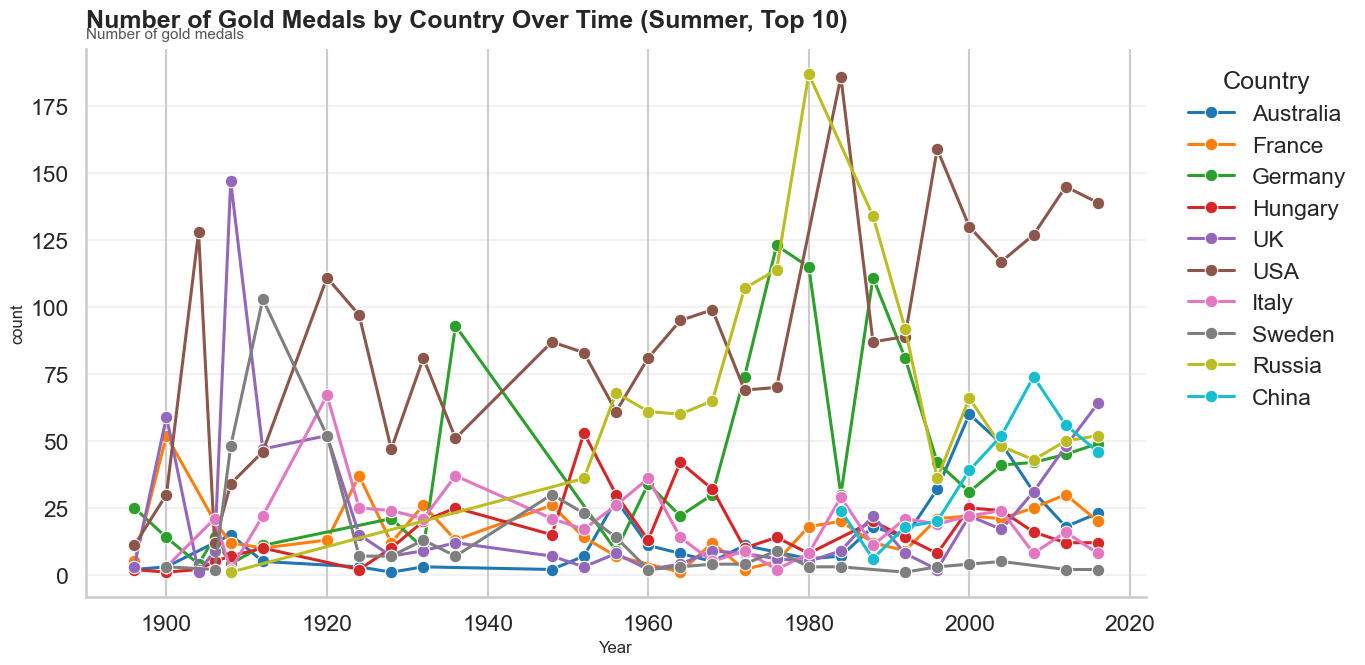

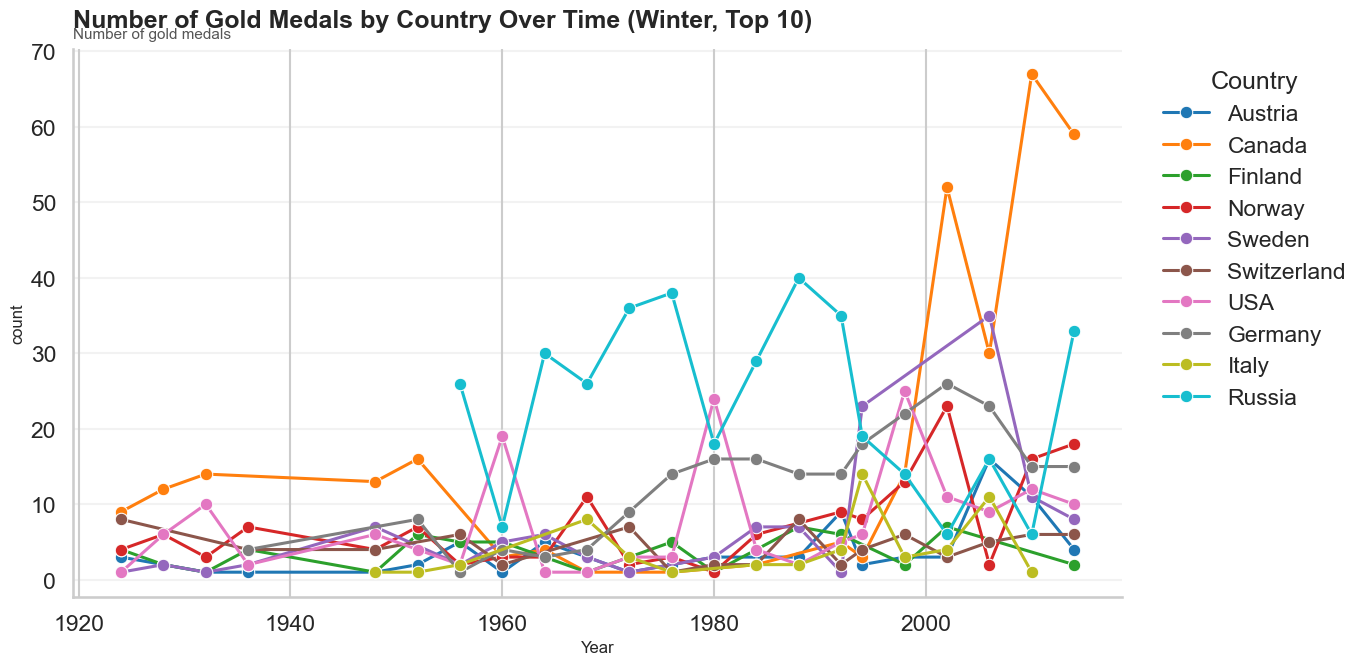

In [420]:
plot_gold_medals_trend("Summer")
plot_gold_medals_trend("Winter")

### 5.4 Countries with many participants but no medals

In [421]:
all_countries = set(olympics["country"].dropna().unique())
medal_countries = set(olympics.loc[olympics["medal"].notna(), "country"].dropna().unique())

never_medaled = sorted(all_countries - medal_countries)

never_medaled_df = (
    olympics[olympics["country"].isin(never_medaled)]
    .groupby("country")
    .agg(
        participations=("id", "count"),
        sports=("sport", "nunique")
    )
    .sort_values("participations", ascending=False)
    .reset_index()
)

print(f"Number of countries that never won a medal: {len(never_medaled_df)}")
never_medaled_df.head(10)

Number of countries that never won a medal: 69


,country,participations,sports
0,Angola,267,11
1,El Salvador,218,14
2,Honduras,189,13
3,San Marino,181,14
4,Andorra,169,12
5,Boliva,152,16
6,Bosnia and Herzegovina,134,15
7,Antigua,133,6
8,Nicaragua,129,10
9,Madagascar,119,9


C:\Users\salve\AppData\Local\Temp\ipykernel_28144\2513163752.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


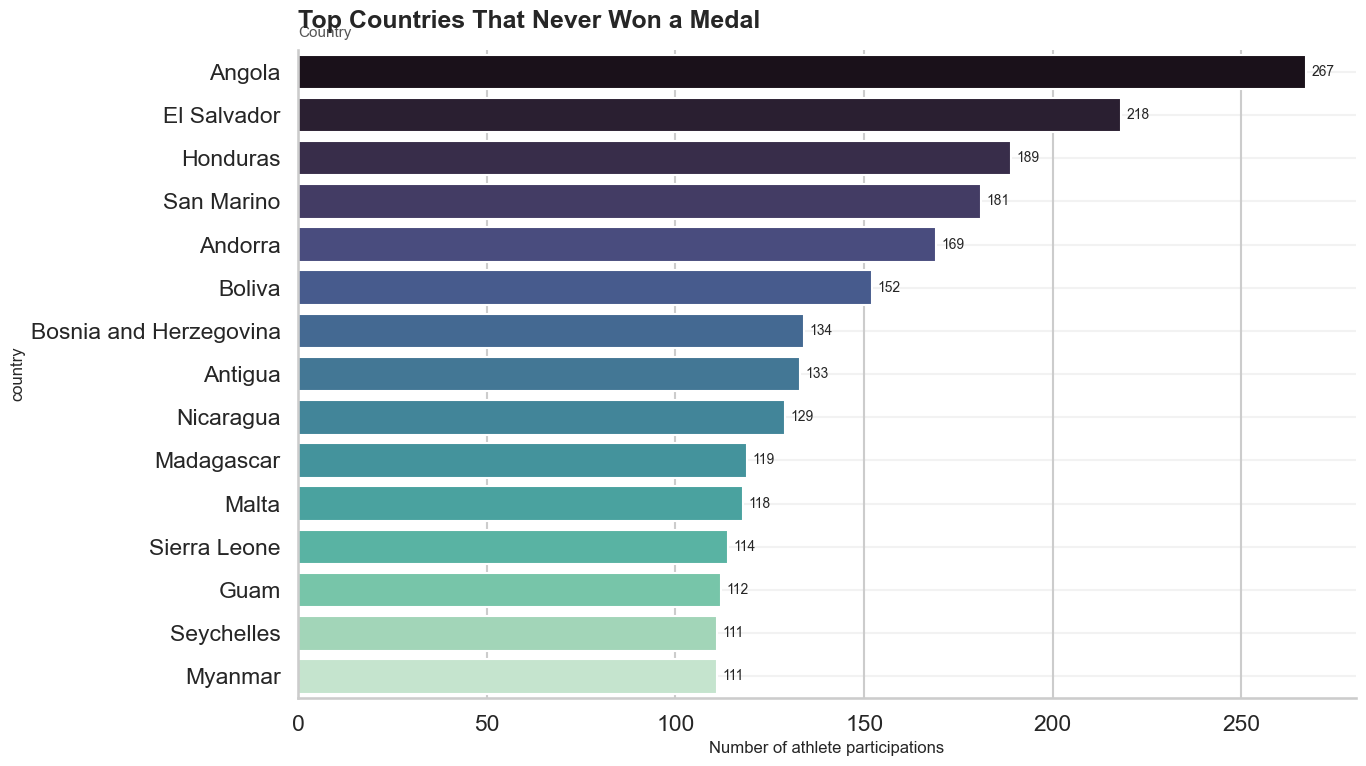

In [422]:
plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=never_medaled_df.head(15),
    x="participations",
    y="country",
    palette="mako",
)
polish_axes(
    ax,
    "Top Countries That Never Won a Medal",
    "Country",
    "Number of athlete participations",
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=4, fontsize=10)
plt.tight_layout()
plt.show()


## 6 Economic Inequality

### 6.1 Medals vs GDP

In [423]:
medals_df = olympics[
    olympics["medal"].notna() &
    olympics["gdp_per_capita"].notna() &
    olympics["population"].notna()
].copy()

country_medals = (
    medals_df
    .groupby(["year", "country"], as_index=False)
    .agg(
        medal_count=("medal", "count"),
        gdp_per_capita=("gdp_per_capita", "median"),
        population=("population", "median")
    )
)

fig = px.scatter(
    country_medals,
    x="gdp_per_capita",
    y="medal_count",
    size="population",
    color="medal_count",
    animation_frame="year",
    hover_name="country",
    title="GDP per Capita vs Medal Count Over Time",
    labels={
        "gdp_per_capita": "GDP per Capita (USD)",
        "medal_count": "Total Medal Count",
        "population": "Population",
        "year": "Year"
    },
    size_max=60,
    template="plotly_white",
    color_continuous_scale="Plasma",
    range_x=[0, country_medals["gdp_per_capita"].max() * 1.05],
    range_y=[0, country_medals["medal_count"].max() * 1.1]
)

fig.update_traces(marker=dict(line=dict(width=0.4, color="white"), opacity=0.75))
fig.show()

### 6.2 Medals vs population

In [424]:
medals_df = olympics[
    olympics["medal"].notna() &
    olympics["population"].notna()
].copy()

country_year = (
    medals_df
    .groupby(["year", "country"], as_index=False)
    .agg(
        medal_count=("medal", "count"),
        population=("population", "median")
    )
)

# Compute medals per million people
country_year["medals_per_million"] = (
    country_year["medal_count"] / country_year["population"] * 1_000_000
)

# Optional: filter out tiny countries to avoid extreme values
country_year = country_year[country_year["population"] > 1_000_000]

fig = px.scatter(
    country_year,
    x="population",
    y="medals_per_million",
    size="medal_count",
    color="country",
    hover_name="country",
    animation_frame="year",
    log_x=True,
    size_max=50,
    title="Olympic Performance vs Population (Medals per Million)"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Population (log scale)",
    yaxis_title="Medals per Million People",
    showlegend=False
)

fig.show()

## 7 Athlete Characteristics

### 7.1 Age distribution

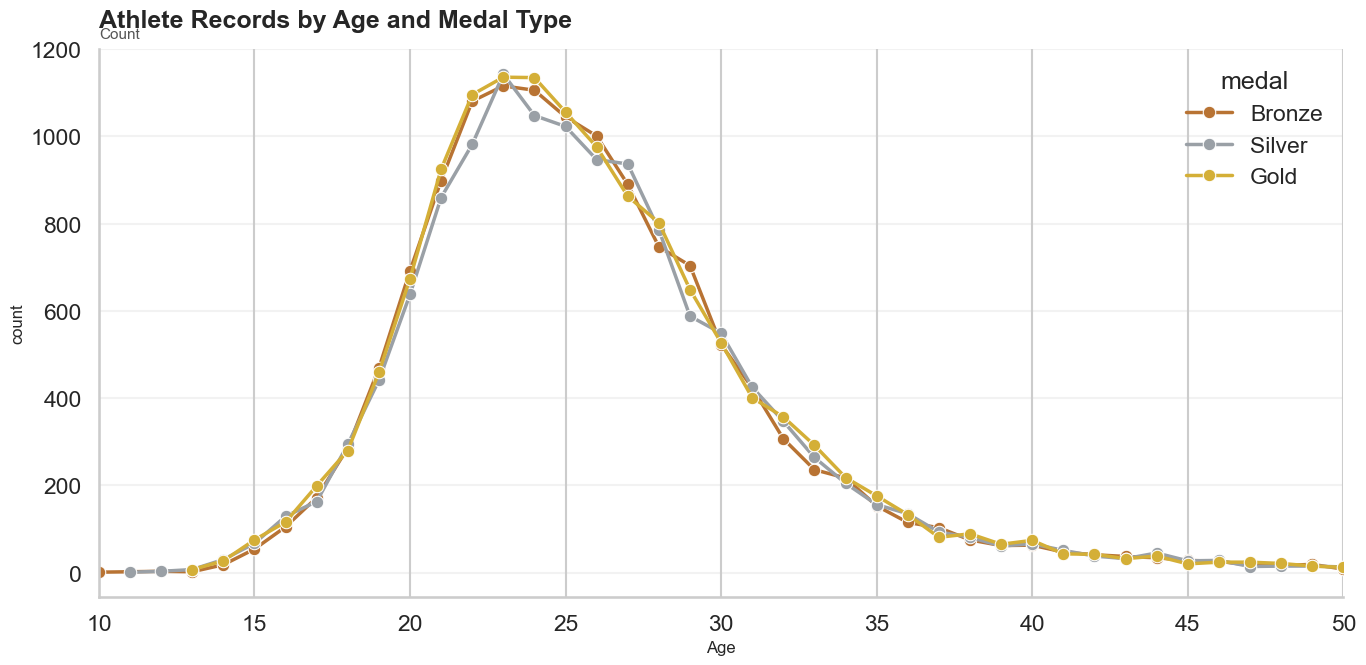

In [425]:
medals_age = olympics.dropna(subset=["age"]).copy()

age_medal = (
    medals_age.groupby(["age", "medal"])
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(14, 7))
ax = sns.lineplot(
    data=age_medal,
    x="age",
    y="count",
    hue="medal",
    palette=PALETTES["medals"],
    linewidth=2.5,
    marker="o",
)
polish_axes(
    ax,
    "Athlete Records by Age and Medal Type",
    "Count",
    "Age",
)
ax.set_xlim(10, 50)
plt.tight_layout()
plt.show()


### 7.2 Age and medal performance

C:\Users\salve\AppData\Local\Temp\ipykernel_28144\1600572261.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


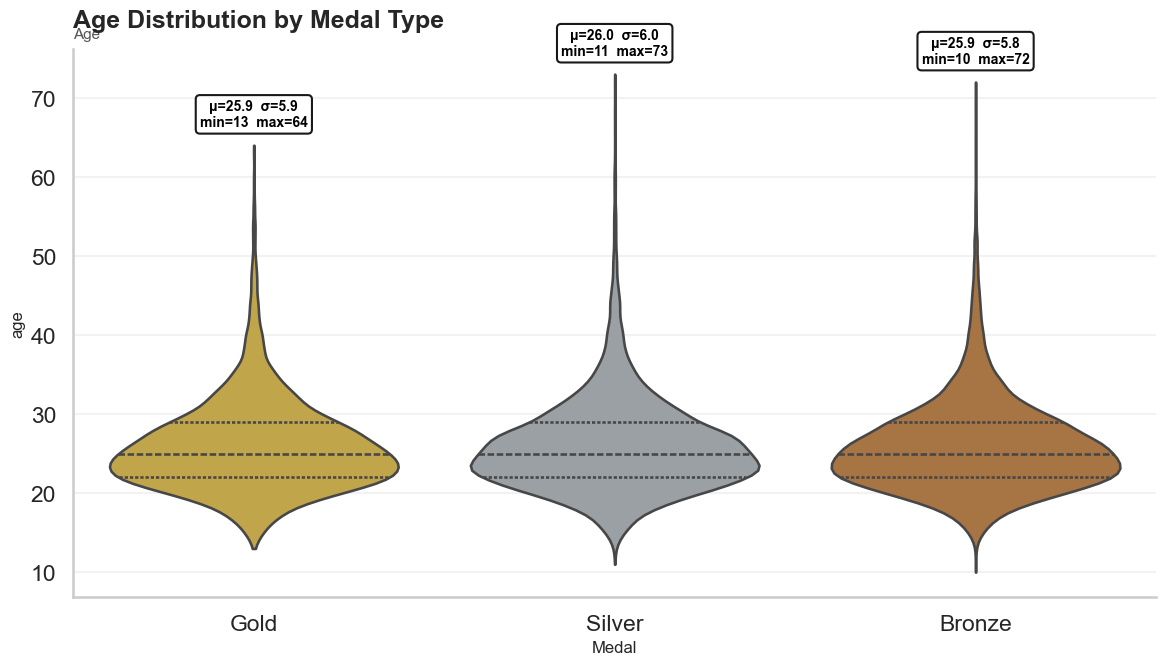

In [426]:
fig, ax = plt.subplots(figsize=(12, 7))

df = olympics.dropna(subset=["age", "medal"]).copy()

order = ["Gold", "Silver", "Bronze"]
df["medal"] = pd.Categorical(df["medal"], categories=order, ordered=True)

sns.violinplot(
    data=df,
    x="medal",
    y="age",
    order=order,
    palette=PALETTES["medals"],
    inner="quartile",
    cut=0,
    ax=ax,
)

stats = df.groupby("medal")["age"].agg(["mean", "std", "min", "max"]).reindex(order)

for i, medal in enumerate(order):
    mean = stats.loc[medal, "mean"]
    std = stats.loc[medal, "std"]
    min_val = stats.loc[medal, "min"]
    max_val = stats.loc[medal, "max"]

    ax.text(
        i,
        max_val + 2,
        f"μ={mean:.1f}  σ={std:.1f}\nmin={min_val:.0f}  max={max_val:.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="black",
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round,pad=0.3",
            alpha=0.9
        )
    )

polish_axes(
    ax,
    "Age Distribution by Medal Type",
    "Age",
    "Medal",
)

plt.tight_layout()
plt.show()

### 7.3 Height vs weight

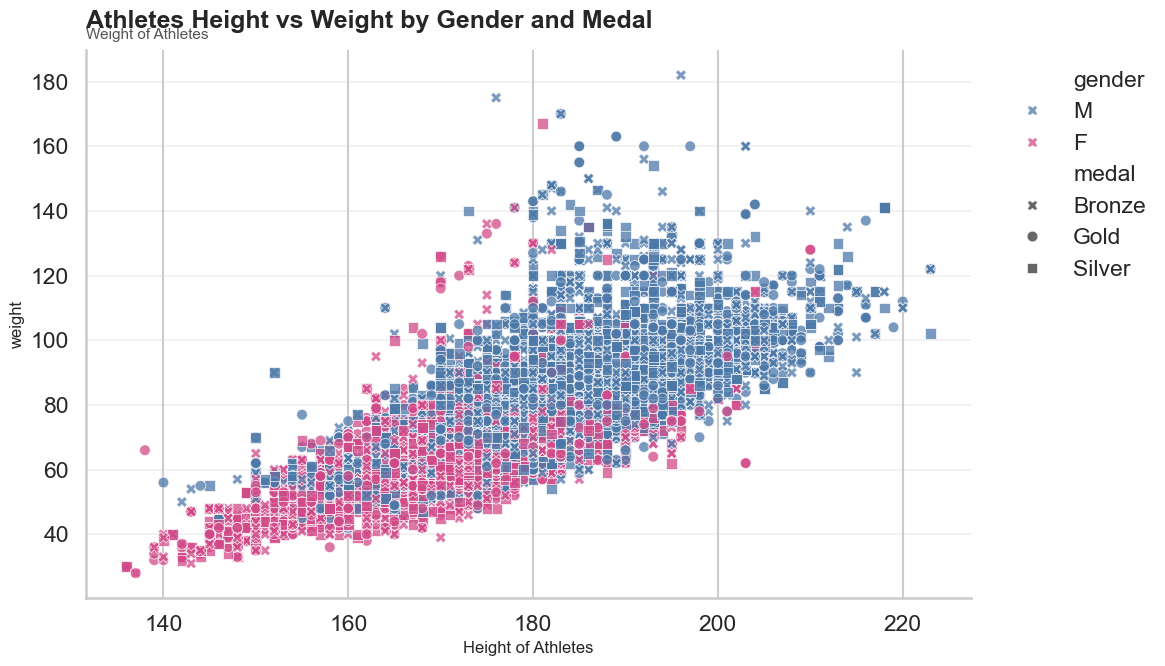

In [427]:
height_weight_medals = olympics.dropna(subset=["height", "weight", "gender", "medal"]).copy()
height_weight_medals = height_weight_medals[
    height_weight_medals["medal"].isin(["Gold", "Silver", "Bronze"])
]

fig, ax = plt.subplots(figsize=(12, 7))

sns.scatterplot(
    data=height_weight_medals,
    x="height",
    y="weight",
    hue="gender",
    style="medal",
    palette={
        "M": "#4C78A8",
        "F": "#d14988"
    },
    markers={
        "Gold": "o",
        "Silver": "s",
        "Bronze": "X"
    },
    alpha=0.75,
    s=60,
    ax=ax
)

polish_axes(
    ax,
    "Athletes Height vs Weight by Gender and Medal",
    "Weight of Athletes",
    "Height of Athletes",
)

plt.legend(title=None, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 8 Conflicts & Geopolitics

### 8.1 Conflits around the world

In [428]:
# Mark conflict during Olympic year
olympics["conflict_active"] = (
    (olympics["year"] >= olympics["conflict_start"]) &
    (olympics["year"] <= olympics["conflict_end"])
)

# One row per country-year
country_year_conflict = (
    olympics.groupby(["year", "country"], as_index=False)
    .agg(conflict_active=("conflict_active", "max"))
)

# Fix country names for Plotly
country_map = {
    "USA": "United States",
    "UK": "United Kingdom",
    "Russia": "Russian Federation",
    "South Korea": "South Korea",
    "North Korea": "North Korea",
    "Iran": "Iran",
    "Iraq": "Iraq",
    "Saudi Arabia": "Saudi Arabia"
}

country_year_conflict["country_plotly"] = (
    country_year_conflict["country"]
    .replace(country_map)
)

# Numeric flag for coloring
country_year_conflict["conflict_flag"] = country_year_conflict["conflict_active"].astype(int)

fig = px.choropleth(
    country_year_conflict,
    locations="country_plotly",
    locationmode="country names",
    color="conflict_flag",
    animation_frame="year",
    hover_name="country",
    hover_data={"conflict_flag": False, "conflict_active": True},
    title="Countries in Conflict During Olympic Years",
    color_continuous_scale=[
        (0.0, "white"),
        (0.5, "white"),
        (0.5, "red"),
        (1.0, "red"),
    ],
    range_color=[0, 1],
)

fig.update_geos(
    showcoastlines=True,
    showcountries=True,
    showland=True,
    landcolor="white",
    bgcolor="rgba(0,0,0,0)"
)

fig.update_layout(
    template="plotly_white",
    coloraxis_colorbar=dict(
        title="Conflict",
        tickvals=[0, 1],
        ticktext=["No", "Yes"]
    )
)

fig.show()

C:\Users\salve\AppData\Local\Temp\ipykernel_28144\2863191686.py:33: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


### 8.2 USA medal count over time (conflicts vs non conflicts)

In [429]:
def plot_conflict_impact_by_season(season):

    season_df = olympics[olympics["season"] == season].copy()

    season_df["conflict_active"] = (
        (season_df["year"] >= season_df["conflict_start"]) &
        (season_df["year"] <= season_df["conflict_end"])
    )

    country_conflict_years = (
        season_df.groupby("country")
        .apply(lambda x: x.loc[x["conflict_active"], "year"].nunique())
        .reset_index(name="conflict_years")
        .sort_values("conflict_years", ascending=False)
    )

    most_impacted_country = country_conflict_years.iloc[0]["country"]
    print(f"Most conflict-affected country in {season}: {most_impacted_country}")

    country_years = season_df[season_df["country"] == most_impacted_country].copy()

    year_summary = (
        country_years.groupby("year")
        .agg(
            medal_count=("medal", lambda x: x.notna().sum()),
            conflict_active=("conflict_active", "max")
        )
        .reset_index()
        .sort_values("year")
    )

    fig, ax = plt.subplots(figsize=(14, 6))

    sns.lineplot(
        data=year_summary,
        x="year",
        y="medal_count",
        marker="o",
        linewidth=2.5,
        color="#355070",
        ax=ax,
        label="Medal count"
    )

    conflict_points = year_summary[year_summary["conflict_active"]]
    ax.scatter(
        conflict_points["year"],
        conflict_points["medal_count"],
        color="#bc5090",
        s=90,
        zorder=3,
        label="Conflict-active year"
    )

    for year in conflict_points["year"]:
        ax.axvspan(year - 1.5, year + 1.5, color="#f3c4d7", alpha=0.18)

    polish_axes(
        ax,
        f"{most_impacted_country}: Medal Count Over Time ({season})",
        "Medal Count",
        "Year"
    )

    ax.legend()
    plt.tight_layout()
    plt.show()

Most conflict-affected country in Summer: USA


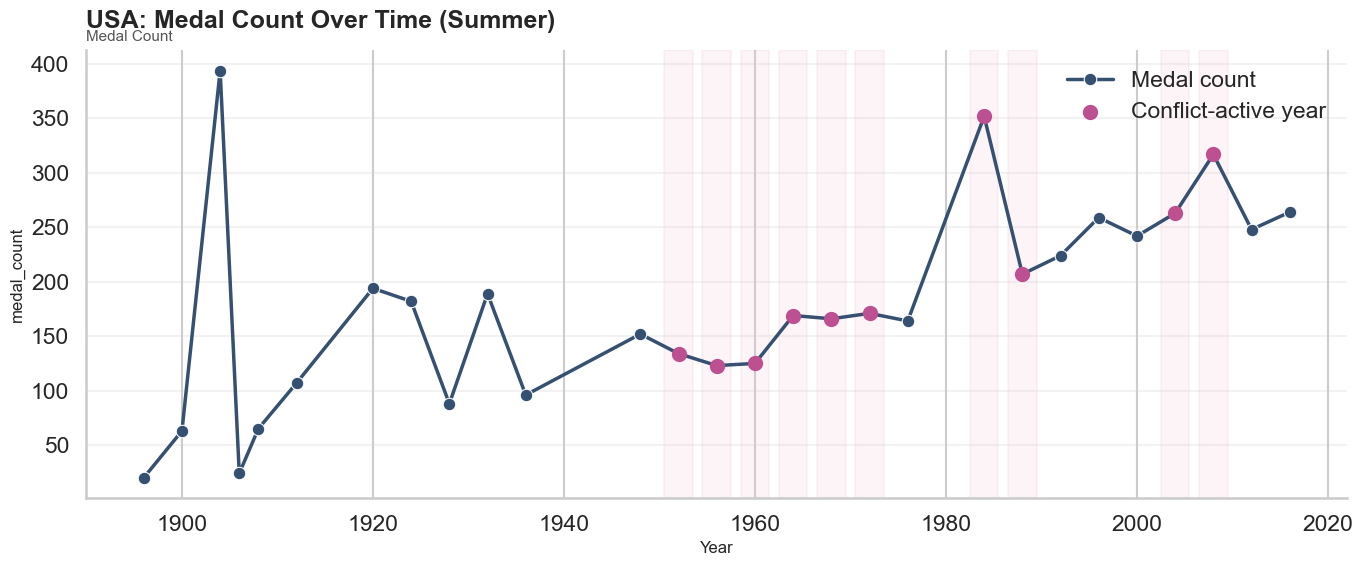

Most conflict-affected country in Winter: USA


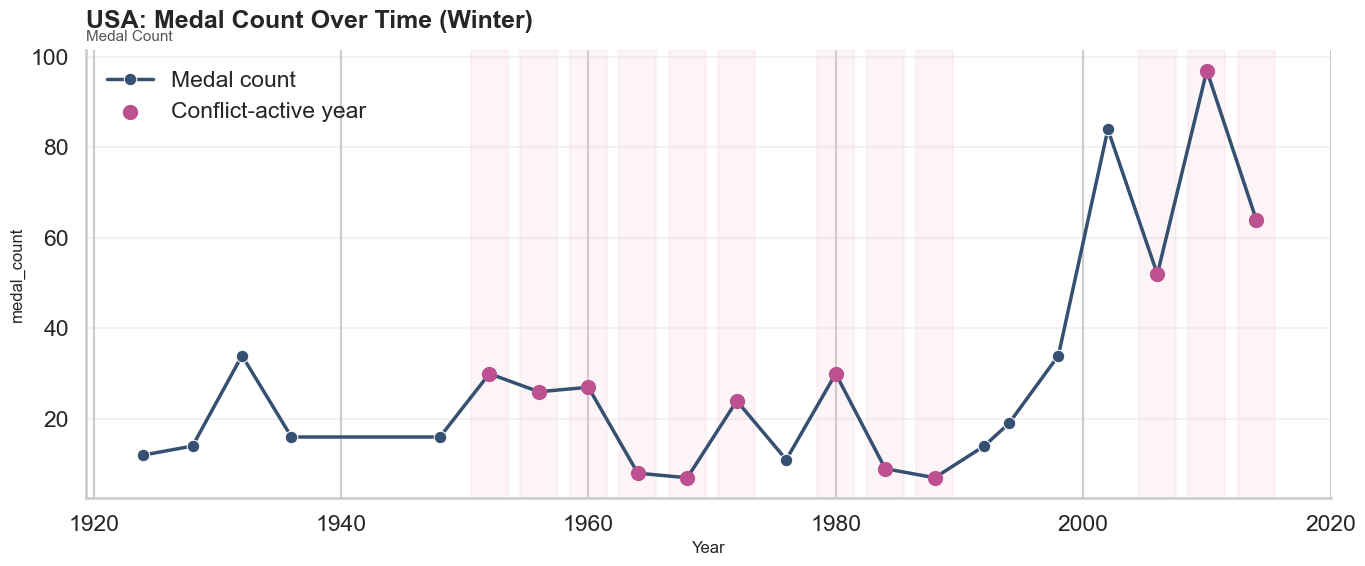

In [430]:
plot_conflict_impact_by_season("Summer")
plot_conflict_impact_by_season("Winter")